# Predicting Insurance Premiums with Data-Driven Insights for SecureLife Insurance Co.

# Domain Knowledge:
## About SecureLife Insurance Co.

![SecureLife](https://drive.google.com/uc?export=view&id=1uMGZfZRIQIRGx0pTD3zcENjOCMHAOhx8)

Founded in 1995, SecureLife Insurance Co. is a leading provider of personal and commercial insurance products. With a strong commitment to innovation and customer-centric policies, SecureLife serves over 10 million policyholders across Africa.

### Mission:

To deliver affordable, reliable, and tailored insurance solutions that protect what matters most to our customers.

### Vision:

To be the most trusted name in insurance by leveraging technology and data-driven insights to improve the customer experience.

### Key Facts:

- Headquarters: Lagos, Nigeria
- Revenue: $3.5 billion annually
- Employees: 8,000+
- Customer Satisfaction Rating: 4.8/5 (based on internal surveys)
- Products Offered:
  - Auto Insurance
  - Health Insurance
  - Home Insurance
  - Life Insurance
  - Specialty Products (e.g., Travel, Pet Insurance)

### Core Values:

- Integrity: Always prioritize ethical practices.
- Innovation: Leverage cutting-edge technology to serve customers better.
- Customer-Centricity: Deliver products and services tailored to individual needs.
- Sustainability: Support green initiatives and sustainable practices.

### Recent Initiatives:

- Digital Transformation: SecureLife has adopted a fully digital claims process, reducing claim settlement times by 40%.
- AI-Powered Premium Estimation: The company is developing machine learning models to provide personalized premium quotes in real time.
- Community Outreach: SecureLife donates 5% of annual profits to support disaster relief and education initiatives.

<hr>



## Overview/Problem statement

Insurance companies like SecureLife Insurance Co. rely heavily on accurate premium prediction models to balance competitiveness with profitability. You are a data scientist recently hired by this leading insurance company (I mean look at their stats) to develop a predictive model for estimating insurance premiums. As a data scientist that you are, you will be responsible for end-to-end development: from data preprocessing and exploratory analysis to model building and evaluation.

## Objective

Develop a regression model to predict the Premium Amount based on the data provided. The key objectives are:

- Clean and preprocess the dataset.
- Explore feature importance and relationships.
- Build and evaluate a robust predictive model.
- Interpret results and provide actionable insights.

## About the Data

The dataset contains over 200,000 records with 20 features, designed to mimic real-world scenarios in the insurance domain. It includes a mix of numerical, categorical, and textual data with challenges such as missing values, skewed distributions, and improperly formatted fields. The target variable is "Premium Amount", representing the insurance premium to be predicted.

| **Feature**            | **Description**                                                                 |
|-------------------------|---------------------------------------------------------------------------------|
| **Age**                | Age of the insured individual (Numerical)                                       |
| **Gender**             | Gender of the insured individual (Categorical: Male, Female)                   |
| **Annual Income**      | Annual income of the insured individual (Numerical, skewed)                    |
| **Marital Status**     | Marital status of the insured individual (Categorical: Single, Married, Divorced) |
| **Number of Dependents** | Number of dependents (Numerical, with missing values)                          |
| **Education Level**    | Highest education level attained (Categorical: High School, Bachelor's, Master's, PhD) |
| **Occupation**         | Occupation of the insured individual (Categorical: Employed, Self-Employed, Unemployed) |
| **Health Score**       | A score representing the health status (Numerical, skewed)                     |
| **Location**           | Type of location (Categorical: Urban, Suburban, Rural)                         |
| **Policy Type**        | Type of insurance policy (Categorical: Basic, Comprehensive, Premium)          |
| **Previous Claims**    | Number of previous claims made (Numerical, with outliers)                      |
| **Vehicle Age**        | Age of the vehicle insured (Numerical)                                         |
| **Credit Score**       | Credit score of the insured individual (Numerical, with missing values)        |
| **Insurance Duration** | Duration of the insurance policy (Numerical, in years)                         |
| **Premium Amount**     | Target variable representing the insurance premium amount (Numerical, skewed)  |
| **Policy Start Date**  | Start date of the insurance policy (Text, improperly formatted)                |
| **Customer Feedback**  | Short feedback comments from customers (Text)                                  |
| **Smoking Status**     | Smoking status of the insured individual (Categorical: Yes, No)                |
| **Exercise Frequency** | Frequency of exercise (Categorical: Daily, Weekly, Monthly, Rarely)            |
| **Property Type**      | Type of property owned (Categorical: House, Apartment, Condo)                  |


**You would find the dataset at: "[Insurance Premium Prediction Dataset.csv](https://drive.google.com/file/d/1bQ8RE4HrVakjJlWlfDmmy6OiwyYa4wdB/view?usp=drive_link)"**

<hr><hr>

# CAPSTONE PROJECT 1 - Insurance Premium Predictive Model
<hr><hr>

### Import Libraries

In [65]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn import metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, classification_report
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, validation_curve
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, AdaBoostClassifier

from scipy import stats
from scipy.stats import kurtosis, skew
# from xgboost import XGBRegressor
from time import time

import warnings
warnings.filterwarnings('ignore')

In [6]:
# load dataset
df = pd.read_csv('Insurance Premium Prediction Dataset.csv')

df.head()

,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type
0,56.0,Male,99990.0,Married,1.0,Master's,NaN,31.074627,Urban,Comprehensive,NaN,13,320.0,5,308.0,2022-12-10 15:21:39.078837,Poor,Yes,Daily,Condo
1,46.0,Male,2867.0,Single,1.0,Bachelor's,NaN,50.271335,Urban,Comprehensive,NaN,3,694.0,4,517.0,2023-01-31 15:21:39.078837,Good,Yes,Monthly,House
2,32.0,Female,30154.0,Divorced,3.0,Bachelor's,NaN,14.714909,Suburban,Comprehensive,2.0,16,652.0,8,849.0,2023-11-26 15:21:39.078837,Poor,No,Monthly,House
3,60.0,Female,48371.0,Divorced,0.0,PhD,Self-Employed,25.346926,Rural,Comprehensive,1.0,11,330.0,7,927.0,2023-02-27 15:21:39.078837,Poor,No,Rarely,Condo
4,25.0,Female,54174.0,Divorced,0.0,High School,Self-Employed,6.659499,Urban,Comprehensive,NaN,9,NaN,8,303.0,2020-11-25 15:21:39.078837,Poor,No,Rarely,Condo


### Data Overview

In [11]:
# information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278860 entries, 0 to 278859
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Age                   274175 non-null  float64
 1   Gender                278860 non-null  object 
 2   Annual Income         264905 non-null  float64
 3   Marital Status        273841 non-null  object 
 4   Number of Dependents  250974 non-null  float64
 5   Education Level       278860 non-null  object 
 6   Occupation            197572 non-null  object 
 7   Health Score          268263 non-null  float64
 8   Location              278860 non-null  object 
 9   Policy Type           278860 non-null  object 
 10  Previous Claims       197572 non-null  float64
 11  Vehicle Age           278860 non-null  int64  
 12  Credit Score          250974 non-null  float64
 13  Insurance Duration    278860 non-null  int64  
 14  Premium Amount        277019 non-null  float64
 15  

**Comment**: We have some missing values in some of the columns.

In [15]:
df.shape

(278860, 20)

**Comment**: There are `278860` rows and `20` columns in this dataset

In [16]:
df.columns

Index(['Age', 'Gender', 'Annual Income', 'Marital Status',
       'Number of Dependents', 'Education Level', 'Occupation', 'Health Score',
       'Location', 'Policy Type', 'Previous Claims', 'Vehicle Age',
       'Credit Score', 'Insurance Duration', 'Premium Amount',
       'Policy Start Date', 'Customer Feedback', 'Smoking Status',
       'Exercise Frequency', 'Property Type'],
      dtype='object')

In [17]:
df.dtypes

Age                     float64
Gender                   object
Annual Income           float64
Marital Status           object
Number of Dependents    float64
Education Level          object
Occupation               object
Health Score            float64
Location                 object
Policy Type              object
Previous Claims         float64
Vehicle Age               int64
Credit Score            float64
Insurance Duration        int64
Premium Amount          float64
Policy Start Date        object
Customer Feedback        object
Smoking Status           object
Exercise Frequency       object
Property Type            object
dtype: object

In [18]:
# summary statistics of the numerical variables
df.describe()

,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount
count,274175.000000,264905.000000,250974.000000,268263.000000,197572.000000,278860.000000,250974.000000,278860.000000,277019.000000
mean,41.020771,42089.085329,1.998048,28.584290,0.998117,9.520283,574.362049,5.007764,966.118667
std,13.549683,35444.517255,1.412312,15.966208,1.000795,5.767915,158.792037,2.581349,909.404567
min,18.000000,0.000000,0.000000,0.035436,0.000000,0.000000,300.000000,1.000000,0.000000
25%,29.000000,13588.000000,1.000000,16.149890,0.000000,5.000000,437.000000,3.000000,286.000000
50%,41.000000,32191.000000,2.000000,26.451244,1.000000,10.000000,575.000000,5.000000,688.000000
75%,53.000000,62164.000000,3.000000,38.966369,2.000000,15.000000,712.000000,7.000000,1367.000000
max,64.000000,149997.000000,4.000000,93.876090,9.000000,19.000000,849.000000,9.000000,4999.000000


In [23]:
# summary statistics of categorical variables
df.describe(include='object')

,Gender,Marital Status,Education Level,Occupation,Location,Policy Type,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type
count,278860,273841,278860,197572,278860,278860,278860,260511,278860,278860,278860
unique,2,3,4,3,3,3,181607,3,2,4,3
top,Male,Single,PhD,Self-Employed,Suburban,Premium,2022-08-30 15:21:39.134960,Average,Yes,Weekly,House
freq,139754,91497,69955,65908,93482,93298,16,86906,139635,70238,93228


In [25]:
df.nunique()

Age                         47
Gender                       2
Annual Income           101693
Marital Status               3
Number of Dependents         5
Education Level              4
Occupation                   3
Health Score            268263
Location                     3
Policy Type                  3
Previous Claims             10
Vehicle Age                 20
Credit Score               550
Insurance Duration           9
Premium Amount            4949
Policy Start Date       181607
Customer Feedback            3
Smoking Status               2
Exercise Frequency           4
Property Type                3
dtype: int64

In [7]:
# converting all column names to lower case + replacing spaces with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.columns

Index(['age', 'gender', 'annual_income', 'marital_status',
       'number_of_dependents', 'education_level', 'occupation', 'health_score',
       'location', 'policy_type', 'previous_claims', 'vehicle_age',
       'credit_score', 'insurance_duration', 'premium_amount',
       'policy_start_date', 'customer_feedback', 'smoking_status',
       'exercise_frequency', 'property_type'],
      dtype='object')

In [183]:
# Value_counts of the categorical columns
dropped_date_df = df.drop('policy_start_date', axis=1)

cat_df = dropped_date_df.select_dtypes(include='object').columns
for col in cat_df:
    print("*"*5, col, "*"*5)
    count = df[col].value_counts()
    print(count)
    print()

***** gender *****
gender
Male      139754
Female    139106
Name: count, dtype: int64

***** marital_status *****
marital_status
Single      91497
Married     91261
Divorced    91083
Name: count, dtype: int64

***** education_level *****
education_level
PhD            69955
Bachelor's     69930
Master's       69815
High School    69160
Name: count, dtype: int64

***** occupation *****
occupation
Self-Employed    65908
Employed         65899
Unemployed       65765
Name: count, dtype: int64

***** location *****
location
Suburban    93482
Urban       92719
Rural       92659
Name: count, dtype: int64

***** policy_type *****
policy_type
Premium          93298
Basic            93083
Comprehensive    92479
Name: count, dtype: int64

***** customer_feedback *****
customer_feedback
Average    86906
Poor       86872
Good       86733
Name: count, dtype: int64

***** smoking_status *****
smoking_status
Yes    139635
No     139225
Name: count, dtype: int64

***** exercise_frequency *****
exercise

### Standardize Column Formats

In [53]:
df.dtypes

age                     float64
gender                   object
annual_income           float64
marital_status           object
number_of_dependents    float64
education_level          object
occupation               object
health_score            float64
location                 object
policy_type              object
previous_claims         float64
vehicle_age               int64
credit_score            float64
insurance_duration        int64
premium_amount          float64
policy_start_date        object
customer_feedback        object
smoking_status           object
exercise_frequency       object
property_type            object
dtype: object

In [8]:
# Convert policy_start_date to datetime format
df['policy_start_date'] = pd.to_datetime(df['policy_start_date'], errors='coerce')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278860 entries, 0 to 278859
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   age                   274175 non-null  float64       
 1   gender                278860 non-null  object        
 2   annual_income         264905 non-null  float64       
 3   marital_status        273841 non-null  object        
 4   number_of_dependents  250974 non-null  float64       
 5   education_level       278860 non-null  object        
 6   occupation            197572 non-null  object        
 7   health_score          268263 non-null  float64       
 8   location              278860 non-null  object        
 9   policy_type           278860 non-null  object        
 10  previous_claims       197572 non-null  float64       
 11  vehicle_age           278860 non-null  int64         
 12  credit_score          250974 non-null  float64       
 13 

<hr>

## Data Cleaning and Preprocessing

In [186]:
# identify missing values
df.isnull().sum()

age                      4685
gender                      0
annual_income           13955
marital_status           5019
number_of_dependents    27886
education_level             0
occupation              81288
health_score            10597
location                    0
policy_type                 0
previous_claims         81288
vehicle_age                 0
credit_score            27886
insurance_duration          0
premium_amount           1841
policy_start_date           0
customer_feedback       18349
smoking_status              0
exercise_frequency          0
property_type               0
dtype: int64

**Comment**: We detected missing values in some columns `(age, annual_income, marital_status, number_of_dependents, occupation, health_score, previous_claims, credit_score, premium_amount, customer_feedback)`. Let's check the percentage impact of each of these missing values in our dataset.

In [187]:
df.isnull().mean() * 100

age                      1.680055
gender                   0.000000
annual_income            5.004303
marital_status           1.799828
number_of_dependents    10.000000
education_level          0.000000
occupation              29.150111
health_score             3.800115
location                 0.000000
policy_type              0.000000
previous_claims         29.150111
vehicle_age              0.000000
credit_score            10.000000
insurance_duration       0.000000
premium_amount           0.660188
policy_start_date        0.000000
customer_feedback        6.580004
smoking_status           0.000000
exercise_frequency       0.000000
property_type            0.000000
dtype: float64

**Comment**: From our analysis, several columns had missing values, with `Occupation` and `Previous Claims` having the highest percentages `(29.15% each)`, followed by `Credit Score` and `Number of Dependents` `(10% each)`. `Customer Feedback` also had a notable percentage of missing values `(6.58%)`.

In [65]:
# number of columns with all missing values
df.isnull().all(axis=0).sum()

np.int64(0)

In [89]:
# number of rows with all missing values
df.isnull().all(axis=1).sum()

np.int64(0)

In [10]:
# checking rows with more than 5 missing values - removing rows
nan_rows = df[df.isnull().sum(axis=1) >= 6]
nan_rows

,age,gender,annual_income,marital_status,number_of_dependents,education_level,occupation,health_score,location,policy_type,previous_claims,vehicle_age,credit_score,insurance_duration,premium_amount,policy_start_date,customer_feedback,smoking_status,exercise_frequency,property_type
189191,41.0,Female,NaN,Single,4.0,PhD,NaN,NaN,Urban,Premium,NaN,18,NaN,8,NaN,2021-12-01 15:21:39.222387,Poor,Yes,Weekly,House
237650,55.0,Female,NaN,Single,NaN,High School,NaN,NaN,Suburban,Basic,NaN,3,644.0,8,1363.0,2020-07-23 15:21:39.259788,NaN,Yes,Daily,Apartment
247533,NaN,Female,34389.0,Divorced,NaN,Bachelor's,NaN,8.627388,Suburban,Comprehensive,NaN,0,NaN,2,1227.0,2022-02-27 15:21:39.266452,NaN,No,Daily,House


### Handling Missing Value

In [11]:
# dropping rows with more than 5 missing values
df = df.drop([189191, 237650, 247533])

**Comment**: We have successfully dropped rows with more than five missing values from our dataframe. Next, we'll handle missing values using SimpleImputer method (Median, Mode)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 278857 entries, 0 to 278859
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   age                   274173 non-null  float64       
 1   gender                278857 non-null  object        
 2   annual_income         264904 non-null  float64       
 3   marital_status        273838 non-null  object        
 4   number_of_dependents  250973 non-null  float64       
 5   education_level       278857 non-null  object        
 6   occupation            197572 non-null  object        
 7   health_score          268262 non-null  float64       
 8   location              278857 non-null  object        
 9   policy_type           278857 non-null  object        
 10  previous_claims       197572 non-null  float64       
 11  vehicle_age           278857 non-null  int64         
 12  credit_score          250973 non-null  float64       
 13  insu

### Filling missing values using SimpleInputer method - Median

In [143]:
# Check for missing values
df.isnull().sum()

age                      4684
gender                      0
annual_income           13953
marital_status           5019
number_of_dependents    27884
education_level             0
occupation              81285
health_score            10595
location                    0
policy_type                 0
previous_claims         81285
vehicle_age                 0
credit_score            27884
insurance_duration          0
premium_amount           1840
policy_start_date           0
customer_feedback       18347
smoking_status              0
exercise_frequency          0
property_type               0
dtype: int64

**Comment**: Missing values in `previous_claims` could mean *"no history of claim"*, which is a valid assumption. We'll fill this column with 0.

In [13]:
# filling the previous_claims column with 0
df['previous_claims'] = df['previous_claims'].fillna(0)

In [14]:
df.isnull().sum()

age                      4684
gender                      0
annual_income           13953
marital_status           5019
number_of_dependents    27884
education_level             0
occupation              81285
health_score            10595
location                    0
policy_type                 0
previous_claims             0
vehicle_age                 0
credit_score            27884
insurance_duration          0
premium_amount           1840
policy_start_date           0
customer_feedback       18347
smoking_status              0
exercise_frequency          0
property_type               0
dtype: int64

**Comment**: `previous_claims` has been successfully filled with 0. Let's go ahead and impute the rest of the numerical columns with it's median.

In [15]:
# Select all numerical columns
numerical_columns = df.select_dtypes(include=['number']).columns

# impute with median
df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].median())

**Comment**: We successfully inputed the numerical missing values with it's median.

In [16]:
df.isnull().sum()

age                         0
gender                      0
annual_income               0
marital_status           5019
number_of_dependents        0
education_level             0
occupation              81285
health_score                0
location                    0
policy_type                 0
previous_claims             0
vehicle_age                 0
credit_score                0
insurance_duration          0
premium_amount              0
policy_start_date           0
customer_feedback       18347
smoking_status              0
exercise_frequency          0
property_type               0
dtype: int64

**Comment**: The rest of the numerical columns has been successfully filled using `Median` imputation technique.

### Filling missing values of the categorical columns with their Mode

In [17]:
# Imputing the categorical columns with their Mode
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

df[categorical_columns] = df[categorical_columns].apply(lambda col: col.fillna(col.mode()[0]))

In [18]:
df.isnull().sum()

age                     0
gender                  0
annual_income           0
marital_status          0
number_of_dependents    0
education_level         0
occupation              0
health_score            0
location                0
policy_type             0
previous_claims         0
vehicle_age             0
credit_score            0
insurance_duration      0
premium_amount          0
policy_start_date       0
customer_feedback       0
smoking_status          0
exercise_frequency      0
property_type           0
dtype: int64

**Comment**: Now that we have successfully handled the missing values using different methods, let's now convert the age type to `int64`.

In [19]:
df['age'] = df['age'].astype('int64')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 278857 entries, 0 to 278859
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   age                   278857 non-null  int64         
 1   gender                278857 non-null  object        
 2   annual_income         278857 non-null  float64       
 3   marital_status        278857 non-null  object        
 4   number_of_dependents  278857 non-null  float64       
 5   education_level       278857 non-null  object        
 6   occupation            278857 non-null  object        
 7   health_score          278857 non-null  float64       
 8   location              278857 non-null  object        
 9   policy_type           278857 non-null  object        
 10  previous_claims       278857 non-null  float64       
 11  vehicle_age           278857 non-null  int64         
 12  credit_score          278857 non-null  float64       
 13  insu

**Comment**: `age` type converted successfully from `float64` to `int64`.

In [153]:
df.head()

,age,gender,annual_income,marital_status,number_of_dependents,education_level,occupation,health_score,location,policy_type,previous_claims,vehicle_age,credit_score,insurance_duration,premium_amount,policy_start_date,customer_feedback,smoking_status,exercise_frequency,property_type
0,56,Male,99990.0,Married,1.0,Master's,Self-Employed,31.074627,Urban,Comprehensive,0.0,13,320.0,5,308.0,2022-12-10 15:21:39.078837,Poor,Yes,Daily,Condo
1,46,Male,2867.0,Single,1.0,Bachelor's,Self-Employed,50.271335,Urban,Comprehensive,0.0,3,694.0,4,517.0,2023-01-31 15:21:39.078837,Good,Yes,Monthly,House
2,32,Female,30154.0,Divorced,3.0,Bachelor's,Self-Employed,14.714909,Suburban,Comprehensive,2.0,16,652.0,8,849.0,2023-11-26 15:21:39.078837,Poor,No,Monthly,House
3,60,Female,48371.0,Divorced,0.0,PhD,Self-Employed,25.346926,Rural,Comprehensive,1.0,11,330.0,7,927.0,2023-02-27 15:21:39.078837,Poor,No,Rarely,Condo
4,25,Female,54174.0,Divorced,0.0,High School,Self-Employed,6.659499,Urban,Comprehensive,0.0,9,575.0,8,303.0,2020-11-25 15:21:39.078837,Poor,No,Rarely,Condo


### Checking for Duplicates

In [156]:
df.duplicated().sum()

np.int64(0)

**Comment**: There are no duplicate rows in our dataset.

<hr>

## Outlier Detection and Treatment

### Detecting Outliers Using BoxPlot

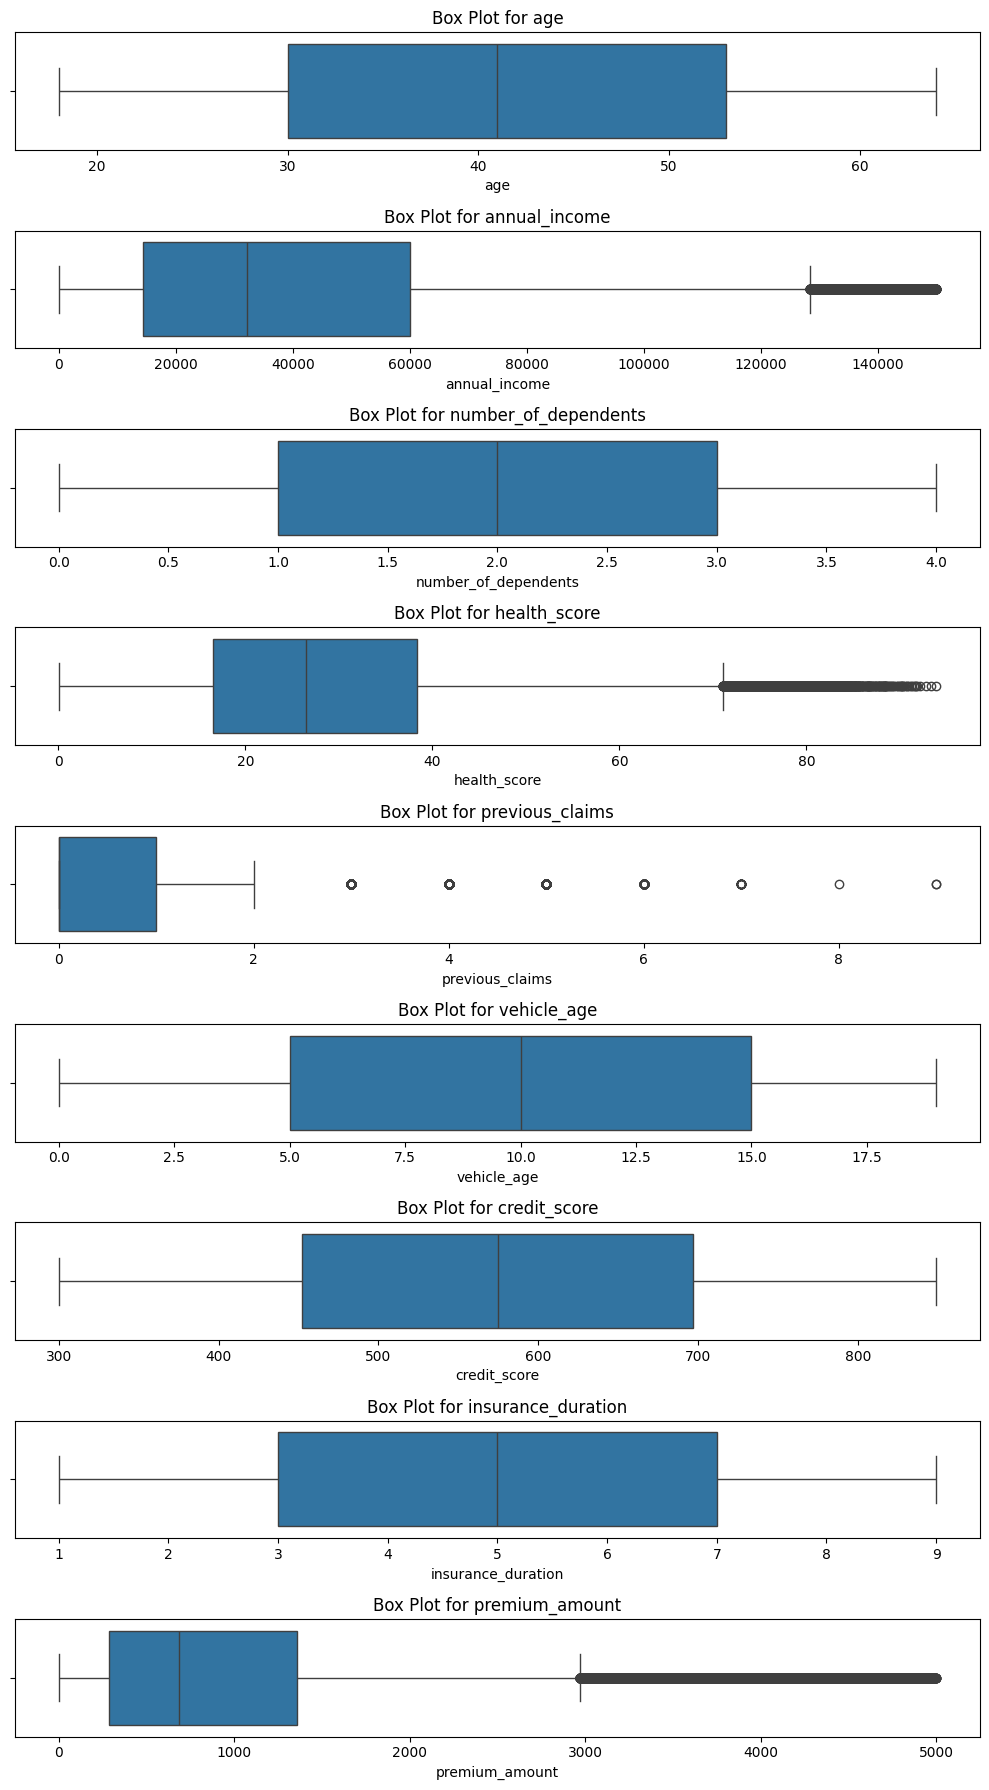

In [21]:
## Detecting outliers on numerical columns

# Filter numerical columns for box plots
numerical_features = df.select_dtypes(include=['number']).columns

# Plot box plots for each numerical feature
plt.figure(figsize=(10, len(numerical_features) * 2))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(len(numerical_features), 1, i)
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot for {col}")
    plt.tight_layout()

plt.show()

#the job of enumerate(numerical_features, 1)
#is to loop over the list 'numerical_features' while also keeping track of an index i starting from 1.

**Insight**

**Age**:

No significant outliers were detected. This suggests that most policyholders fall within a typical age range, with no exceptionally young or old individuals significantly deviating from the norm.

**Annual Income**:

- **Number of Outliers**: 7,553

- **Interpretation**: Outliers in 'Annual Income' might indicate individuals with extremely high or low incomes. Very low incomes could suggest financial instability, while very high incomes might correlate with higher asset values requiring more comprehensive insurance, both potentially affecting insurance risk and premium.

**Number of Dependents**:

No significant outliers were detected. This implies that the number of dependents for policyholders is generally within an expected range.

**Health Score**:

- **Number of Outliers**: 2,457

- **Interpretation**: Outliers in 'Health Score' (very low or very high scores) could indicate individuals with extremely poor or exceptionally good health. This directly influences health-related insurance premiums, as poorer health typically leads to higher premiums due to increased risk.

**Previous Claims**:

- **Number of Outliers**: 15,871

- **Interpretation**: Outliers in 'Previous Claims' represent policyholders with a significantly higher number of past claims than average. This is a critical factor for insurance, as a history of more claims typically leads to higher premiums due to an increased perceived risk.

**Vehicle Age**:

No significant outliers were detected. This suggests that the age of vehicles insured is generally within a common range.

**Credit Score**:

No significant outliers were detected. This indicates that most policyholders have credit scores within a typical distribution.

**Insurance Duration**:

No significant outliers were detected. The duration of insurance policies appears to be within a consistent range.

**Premium Amount**:

- **Number of Outliers**: 12,305

- **Interpretation**: Outliers in 'Premium Amount' represent insurance premiums that are exceptionally high or low compared to the majority. These could be due to unique risk profiles, specific policy coverages (e.g., very high coverage limits leading to high premiums, or very basic coverage leading to low premiums), or potentially data entry errors.

### Treating the outliers using InterQuartileRange(IQR)

In [22]:
# Define the IQR Outlier Removal Function
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

df = df
numerical_columns = df.select_dtypes(include=['number']).columns

for col in numerical_columns:
    df = remove_outliers_iqr(df, col)

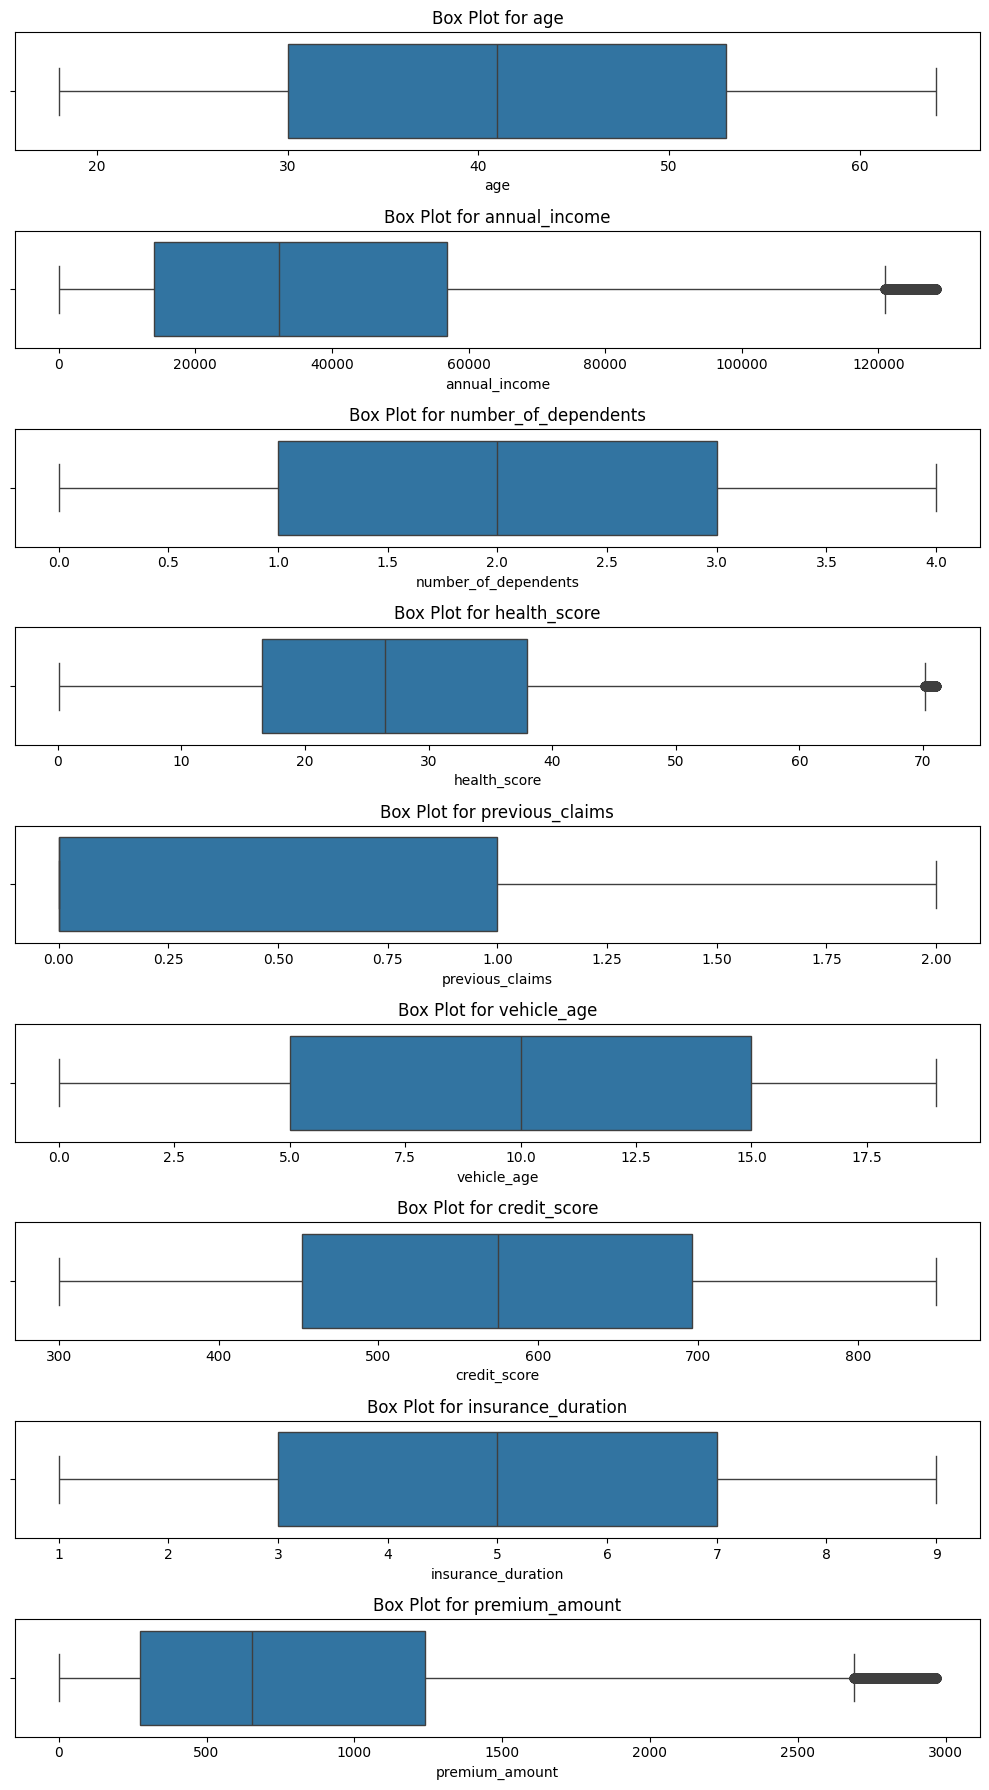

In [23]:
## checking if the outliers on numerical columns was removed successfully

# Filter numerical columns for box plots
numerical_features = df.select_dtypes(include=['number']).columns

# Plot box plots for each numerical feature
plt.figure(figsize=(10, len(numerical_features) * 2))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(len(numerical_features), 1, i)
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot for {col}")
    plt.tight_layout()

plt.show()

#the job of enumerate(numerical_features, 1)
#is to loop over the list 'numerical_features' while also keeping track of an index i starting from 1.

**Insight**: The outliers have not been properly treated. This may introduce `bias` in our model. We'll further handle these outliers with IQR technique until we have a minimal or no outliers to work with.

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 242506 entries, 0 to 278859
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   age                   242506 non-null  int64         
 1   gender                242506 non-null  object        
 2   annual_income         242506 non-null  float64       
 3   marital_status        242506 non-null  object        
 4   number_of_dependents  242506 non-null  float64       
 5   education_level       242506 non-null  object        
 6   occupation            242506 non-null  object        
 7   health_score          242506 non-null  float64       
 8   location              242506 non-null  object        
 9   policy_type           242506 non-null  object        
 10  previous_claims       242506 non-null  float64       
 11  vehicle_age           242506 non-null  int64         
 12  credit_score          242506 non-null  float64       
 13  insu

In [25]:
# Define the IQR Outlier Removal Function
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

df = df
numerical_columns = df.select_dtypes(include=['number']).columns

for col in numerical_columns:
    df = remove_outliers_iqr(df, col)

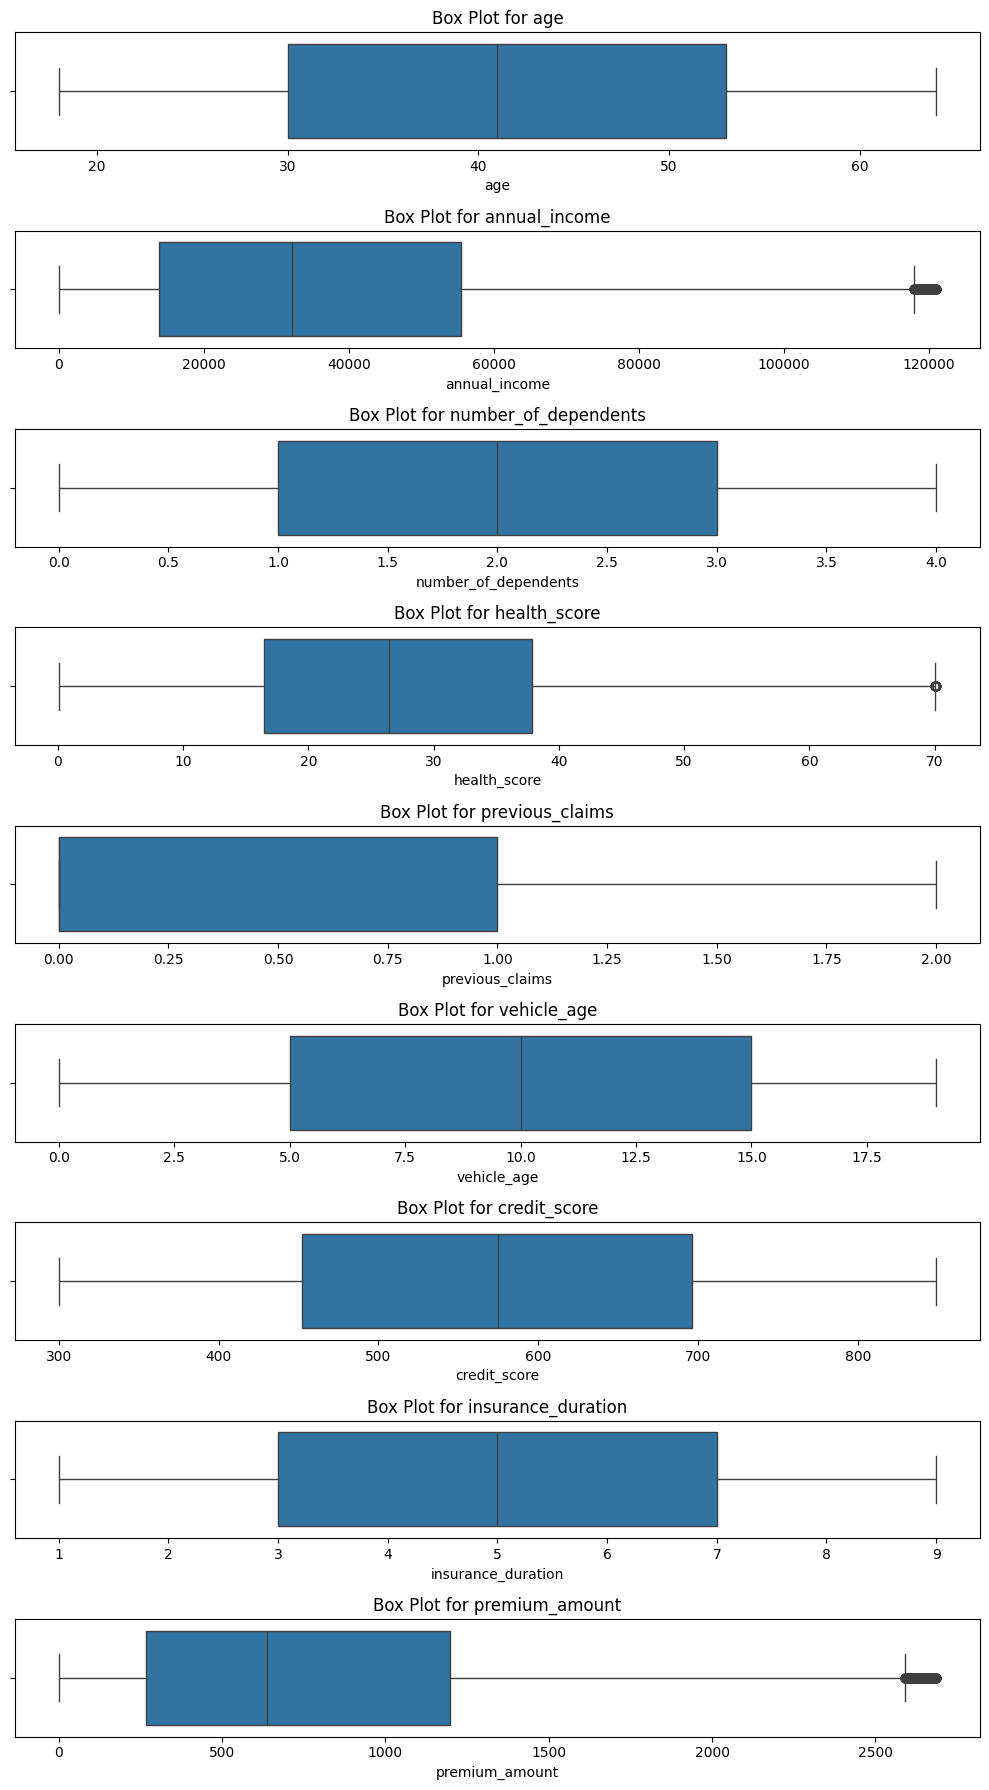

In [26]:
## checking if the outliers on numerical columns was removed successfully

# Filter numerical columns for box plots
numerical_features = df.select_dtypes(include=['number']).columns

# Plot box plots for each numerical feature
plt.figure(figsize=(10, len(numerical_features) * 2))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(len(numerical_features), 1, i)
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot for {col}")
    plt.tight_layout()

plt.show()

#the job of enumerate(numerical_features, 1)
#is to loop over the list 'numerical_features' while also keeping track of an index i starting from 1.

**Insight**: The outliers is now minimal. We now have a clean dataset we can work it. Now we'll proceed with Exploratory Data Analysis to uncover more insights about our dataset.

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 234919 entries, 0 to 278859
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   age                   234919 non-null  int64         
 1   gender                234919 non-null  object        
 2   annual_income         234919 non-null  float64       
 3   marital_status        234919 non-null  object        
 4   number_of_dependents  234919 non-null  float64       
 5   education_level       234919 non-null  object        
 6   occupation            234919 non-null  object        
 7   health_score          234919 non-null  float64       
 8   location              234919 non-null  object        
 9   policy_type           234919 non-null  object        
 10  previous_claims       234919 non-null  float64       
 11  vehicle_age           234919 non-null  int64         
 12  credit_score          234919 non-null  float64       
 13  insu

<hr>

## Exploratory Data Analysis (EDA)
<hr>

## Univariate Analysis
<hr>

### Checking for skewness in the numerical columns

Skewness tells us how asymmetric the distribution of a numerical variable is:

- Positive skew (right-skewed): Long tail on the right → many small values, few large ones.

- Negative skew (left-skewed): Long tail on the left → many large values, few small ones.

- Skewness ≈ 0: Symmetric (normal) distribution — ideal for most regression models.

In [28]:
## Checking for skewness in the numerical columns

# Select numeric columns
numerical_columns = df.select_dtypes(include=['number']).columns

# Calculate skewness
skewness = df[numerical_columns].apply(lambda x: x.skew()).sort_values(ascending=False)

# View highly skewed features (e.g., skewness > 1)
skewed_features = skewness[skewness > 0.5]
print(skewed_features)

previous_claims    0.912855
premium_amount     0.900542
annual_income      0.866093
dtype: float64


In [29]:
for col in numerical_columns:
    print(f"Skewness of {col}: {skew(df[col])}")
    print(f"Kurtosis of {col}: {kurtosis(df[col])}")
    print()

Skewness of age: -0.0033593892419082733
Kurtosis of age: -1.1659785401261484

Skewness of annual_income: 0.8660879228664301
Kurtosis of annual_income: -0.07550025285600581

Skewness of number_of_dependents: -5.66165262827849e-05
Kurtosis of number_of_dependents: -1.1069378192447235

Skewness of health_score: 0.4901203923581387
Kurtosis of health_score: -0.36748377702926494

Skewness of previous_claims: 0.9128493022129988
Kurtosis of previous_claims: -0.5397186004148176

Skewness of vehicle_age: -0.003406402229333526
Kurtosis of vehicle_age: -1.2069466197439829

Skewness of credit_score: 0.0017340683739551957
Kurtosis of credit_score: -0.9976866483935205

Skewness of insurance_duration: -0.0012551360094342921
Kurtosis of insurance_duration: -1.2297469359839281

Skewness of premium_amount: 0.9005361885206653
Kurtosis of premium_amount: -0.032089909529355864



| Feature               | Skewness   | Interpretation                    |
|-----------------------|------------|-----------------------------------|
| `age`                 | -0.003     | Symmetric                         |
| `annual_income`       | 0.866      | **Moderately right-skewed** ✅      |
| `number_of_dependents`| ~0         | Symmetric                         |
| `health_score`        | 0.489      | Slightly right-skewed             |
| `previous_claims`     | 0.913      | **Moderately right-skewed** ✅     |
| `vehicle_age`         | ~0         | Symmetric                         |
| `credit_score`        | ~0         | Symmetric                         |
| `insurance_duration`  | ~0         | Symmetric                         |
| `premium_amount`      | 0.901      | **Moderately right-skewed** ✅      |


**Insight** <br><br>
**Skewness**:
  We can see that 1 feature has moderate skewness and are potential candidates for transformation:
- `previous_claims`



**Kurtosis (Shape of tails)**:

- All values are negative, which indicates light tails or a platykurtic distribution (flatter than normal).

- This is generally fine and not a red flag unless it’s extreme.

### Applying Log Transformation to the moderately skewed features using np.log1p() to reduce the skewness

In [30]:
skewed_features = ['annual_income', 'previous_claims', 'premium_amount']
for feature in skewed_features:
    df[feature] = np.log1p(df[feature])

In [31]:
df[skewed_features].describe()

,annual_income,previous_claims,premium_amount
count,234919.000000,234919.000000,234919.000000
mean,10.085468,0.342624,6.205169
std,1.177304,0.425666,1.203388
min,0.000000,0.000000,0.000000
25%,9.529884,0.000000,5.594711
50%,10.379473,0.000000,6.458338
75%,10.922876,0.693147,7.088409
max,11.703455,1.098612,7.896181


In [32]:
for feature in skewed_features:
    print(f"Skewness of {feature} after log1p: {skew(df[feature])}")

Skewness of annual_income after log1p: -1.449917398703756
Skewness of previous_claims after log1p: 0.6173867465157383
Skewness of premium_amount after log1p: -1.2608996545841058


In [ ]:
df.head()

In [33]:
# Select numeric columns
numerical_columns = df.select_dtypes(include=['number']).columns

# Check for skewness
for col in numerical_columns:
    print(f"Skewness of {col}: {skew(df[col])}")
    print()

Skewness of age: -0.0033593892419082733

Skewness of annual_income: -1.449917398703756

Skewness of number_of_dependents: -5.66165262827849e-05

Skewness of health_score: 0.4901203923581387

Skewness of previous_claims: 0.6173867465157383

Skewness of vehicle_age: -0.003406402229333526

Skewness of credit_score: 0.0017340683739551957

Skewness of insurance_duration: -0.0012551360094342921

Skewness of premium_amount: -1.2608996545841058



**Insight**: After applying *"log tranformation"* on the moderately skewed features columns **"['annual_income', 'previous_claims', 'premium_amount']"**, the skewness of `annual_income` reduced from `0.866` to `-1.450`, the skewness of `previous_claims` reduced from `0.913` to `0.617`, the skewness of `premium_amount` reduced from `0.901` to `-1.261`, indicating a successful skewness reduction.

In [34]:
## let's create a function for numerical analysis

# Select numeric columns
num_df = df.select_dtypes(include=['number'])

def num_univariate_analysis(discrete_data):
    for col_name in discrete_data:
        print("*"*5, col_name, "*"*5)
        print(discrete_data[col_name].agg(['min', 'max', 'mean', 'median', 'std', 'kurt', 'skew']))
        print()

num_univariate_analysis(num_df)

***** age *****
min       18.000000
max       64.000000
mean      41.028482
median    41.000000
std       13.421553
kurt      -1.165978
skew      -0.003359
Name: age, dtype: float64

***** annual_income *****
min        0.000000
max       11.703455
mean      10.085468
median    10.379473
std        1.177304
kurt       3.324561
skew      -1.449927
Name: annual_income, dtype: float64

***** number_of_dependents *****
min       0.000000
max       4.000000
mean      1.998446
median    2.000000
std       1.339609
kurt     -1.106936
skew     -0.000057
Name: number_of_dependents, dtype: float64

***** health_score *****
min        0.073669
max       70.116379
mean      28.012696
median    26.451244
std       14.993506
kurt      -0.367466
skew       0.490124
Name: health_score, dtype: float64

***** previous_claims *****
min       0.000000
max       1.098612
mean      0.342624
median    0.000000
std       0.425666
kurt     -1.262189
skew      0.617391
Name: previous_claims, dtype: float64

***

### Distribution of the Numerical Features (Histogram Plot)

In [35]:
num_cols = len(numerical_columns)
num_cols

9

In [36]:
num_cols // 3

3

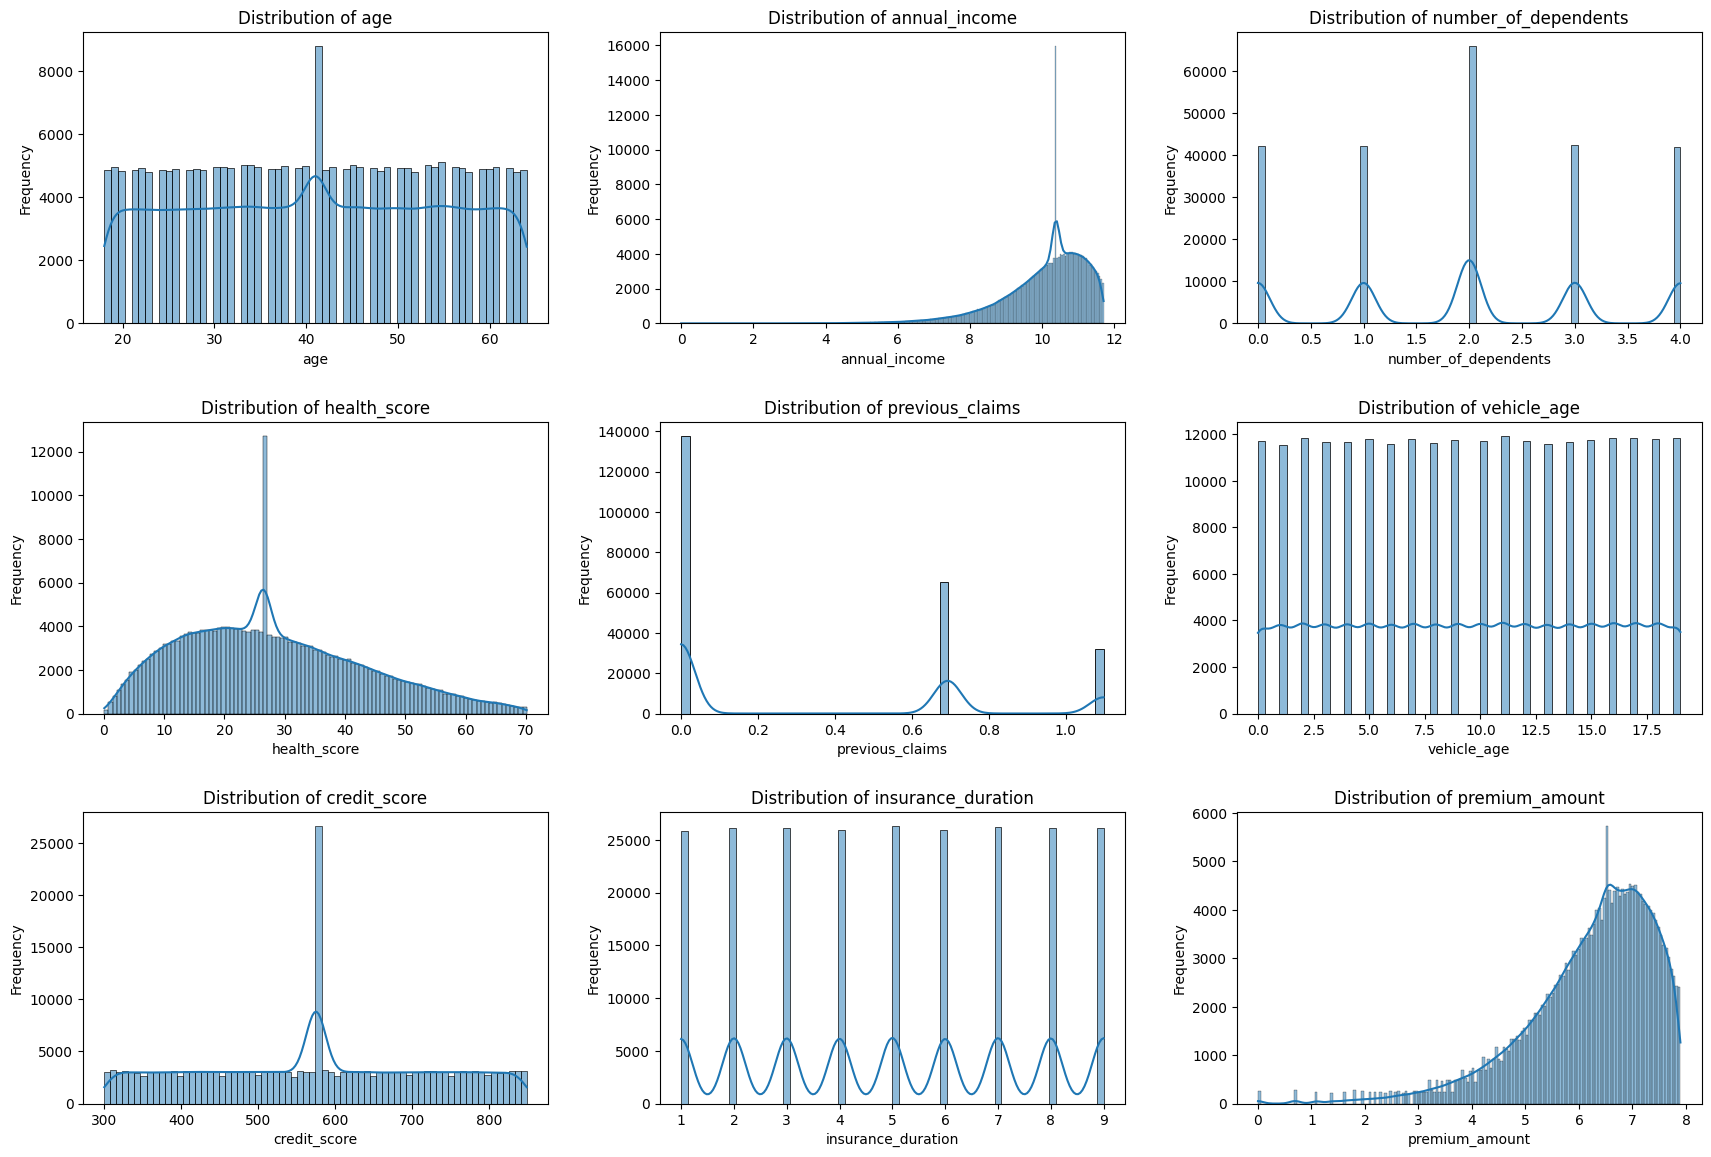

In [37]:
# creating a function to plot the distribution of the variables
def univariate_analysis(df):
    num_cols = len(df.columns)
    fig, axes = plt.subplots(nrows=(num_cols // 3) + 1, ncols=3, figsize=(18, 4 * ((num_cols // 3) + 1)))
    fig.tight_layout(pad=5.0)

    axes = axes.flatten() # Flatten axes array for easy iteration

    for i, col_name in enumerate(numerical_columns):
        sns.histplot(data=df, x=col_name, kde=True, ax=axes[i]) # We used KDE for a smooth distribution curve
        axes[i].set_title(f'Distribution of {col_name}')
        axes[i].set_xlabel(col_name)
        axes[i].set_ylabel('Frequency')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.show()

univariate_analysis(df)

**Insight**: <br>

| Feature               | Skewness   | Interpretation                    |
|-----------------------|------------|-----------------------------------|
| `age`                 | -0.003     | Symmetric                         |
| `annual_income`       | -0.612      | Slightly left-skewed     |
| `number_of_dependents`| ~0         | Symmetric                         |
| `health_score`        | 0.489      | Slightly right-skewed             |
| `previous_claims`     | 0.616      | **Moderately right-skewed** ✅     |
| `vehicle_age`         | ~0         | Symmetric                         |
| `credit_score`        | ~0         | Symmetric                         |
| `insurance_duration`  | ~0         | Symmetric                         |
| `premium_amount`      | -0.615      | Slightly left_skewed      |


In [38]:
# let's create a function for categorical analysis
cat_df = df.select_dtypes(include=['object'])

def cat_univariate_analysis(discrete_data):
    for col_name in discrete_data:
        print("*"*5, col_name, "*"*5)
        print(discrete_data[col_name].agg(['count', 'nunique', 'unique']))
        print()
        print('Value Counts: \n', discrete_data[col_name].value_counts())
        print()

cat_univariate_analysis(cat_df)

***** gender *****
count              234919
nunique                 2
unique     [Male, Female]
Name: gender, dtype: object

Value Counts: 
 gender
Male      117785
Female    117134
Name: count, dtype: int64

***** marital_status *****
count                           234919
nunique                              3
unique     [Married, Single, Divorced]
Name: marital_status, dtype: object

Value Counts: 
 marital_status
Single      81348
Married     77000
Divorced    76571
Name: count, dtype: int64

***** education_level *****
count                                        234919
nunique                                           4
unique     [Master's, Bachelor's, PhD, High School]
Name: education_level, dtype: object

Value Counts: 
 education_level
Bachelor's     58946
PhD            58929
Master's       58723
High School    58321
Name: count, dtype: int64

***** occupation *****
count                                     234919
nunique                                        3
unique     

<hr>

## Bivariate and Multivariate Analysis
<hr>

### Scatter Plot of Numerical Variables vs Target Variable (Numerical vs Numerical)

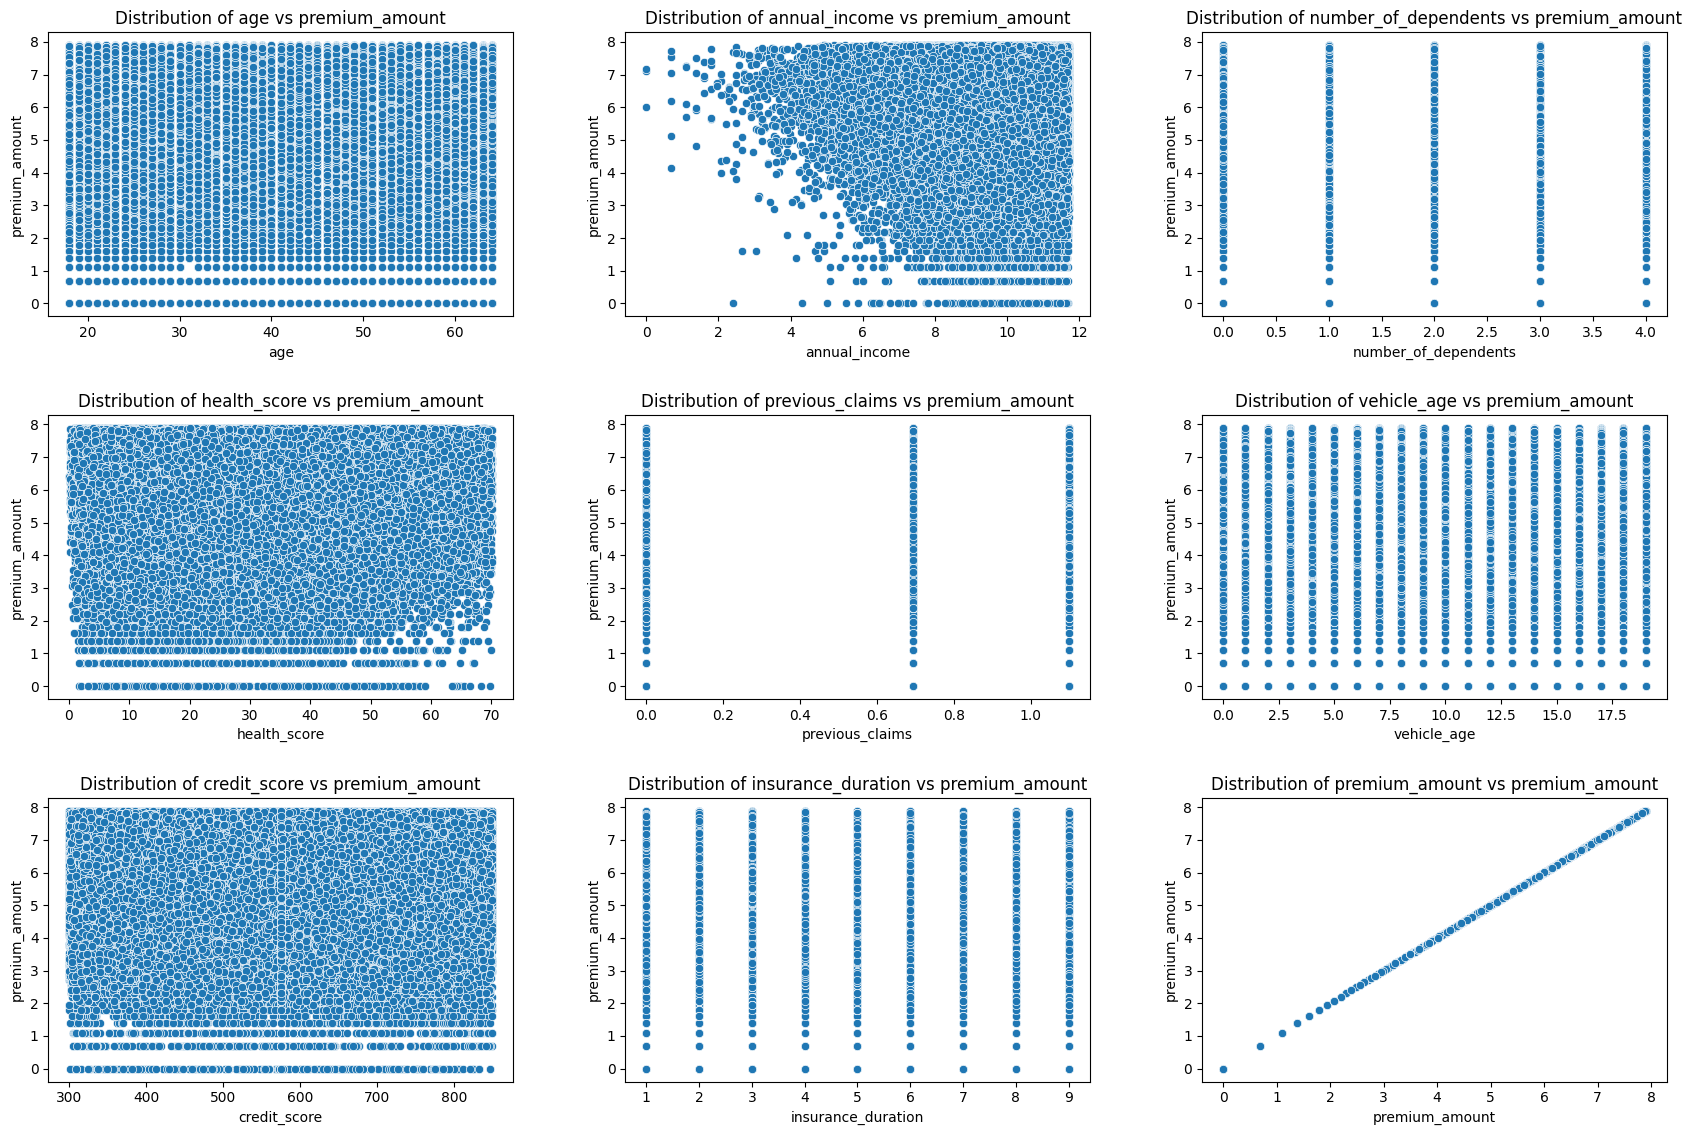

In [40]:
# creating a function to plot the Scatter plots of the numerical variables vs the target variable
num_df = df.select_dtypes(include=['int64', 'float64'])

def univariate_analysis(num_df):
    num_cols = len(num_df.columns)
    fig, axes = plt.subplots(nrows=(num_cols // 3) + 1, ncols=3, figsize=(18, 4 * ((num_cols // 3) + 1)))
    fig.tight_layout(pad=5.0)

    axes = axes.flatten() # Flatten axes array for easy iteration

    for i, col_name in enumerate(numerical_columns):
        sns.scatterplot(data=num_df, x=col_name, y='premium_amount', ax=axes[i])
        axes[i].set_title(f'Distribution of {col_name} vs premium_amount')
        axes[i].set_xlabel(col_name)
        axes[i].set_ylabel('premium_amount')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.show()

univariate_analysis(num_df)

### Use `.corr()` and a heatmap to check for linear relationship

In [41]:
# linear relationship between numerical variables and the target variable (premium_amount)
df.corr(numeric_only=True)['premium_amount'].sort_values(ascending=False)

premium_amount          1.000000
age                     0.004612
health_score            0.004305
vehicle_age             0.001837
number_of_dependents    0.001033
credit_score            0.000648
previous_claims        -0.000061
insurance_duration     -0.000624
annual_income          -0.000679
Name: premium_amount, dtype: float64

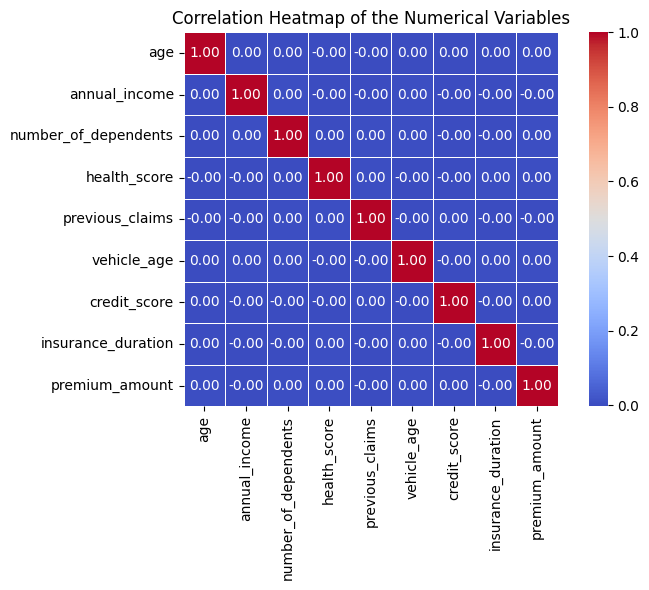

In [42]:
# Using heatmap to show correlation matrix
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, square=True)
plt.title("Correlation Heatmap of the Numerical Variables")

plt.tight_layout()
plt.show()

### Interpreting the Correlation Matrix

**General Guidelines**: <br>
+1.0 → perfect positive correlation

0 → no correlation

-1.0 → perfect negative correlation

> We're most interested in how each feature correlates with premium_amount. <br>

### Correlation Insights with `premium_amount`

| Feature                | Correlation | Interpretation                                                         |
|------------------------|-------------|------------------------------------------------------------------------|
| `annual_income`        | **-0.0004** | **No relationship** — income has virtually no impact on premium.      |
| `health_score`         | **+0.0026** | **No meaningful correlation** — premiums are not influenced by health score. |
| `credit_score`         | **+0.0013** | **No relationship** — credit score doesn't affect premium amount.     |
| `vehicle_age`          | **+0.0011** | No significant pattern — vehicle age is not linked to premium.        |
| `previous_claims`      | **+0.0010** | Very weak — nearly no effect of claims history on premium.            |
| `age`                  | **+0.0028** | No correlation — age is not influencing premium in this dataset.      |
| `number_of_dependents` | **+0.0007** | No relationship — dependents don’t impact premium.                    |
| `insurance_duration`   | **+0.0006** | No correlation — duration of insurance has no impact.                 |

 

**Key Insight**: <br>

All the numerical features show extremely weak (near-zero) correlations with the target variable premium_amount. This tells us:

- Premium amount is likely influenced by categorical features (e.g., gender, vehicle_type, etc.), not numerical ones.

- Non-linear models (like decision trees, random forest, gradient boosting) may uncover patterns not detectable through simple correlation.

### Boxplot of Categorical variables vs Target variable (Categorical vs Numerical)

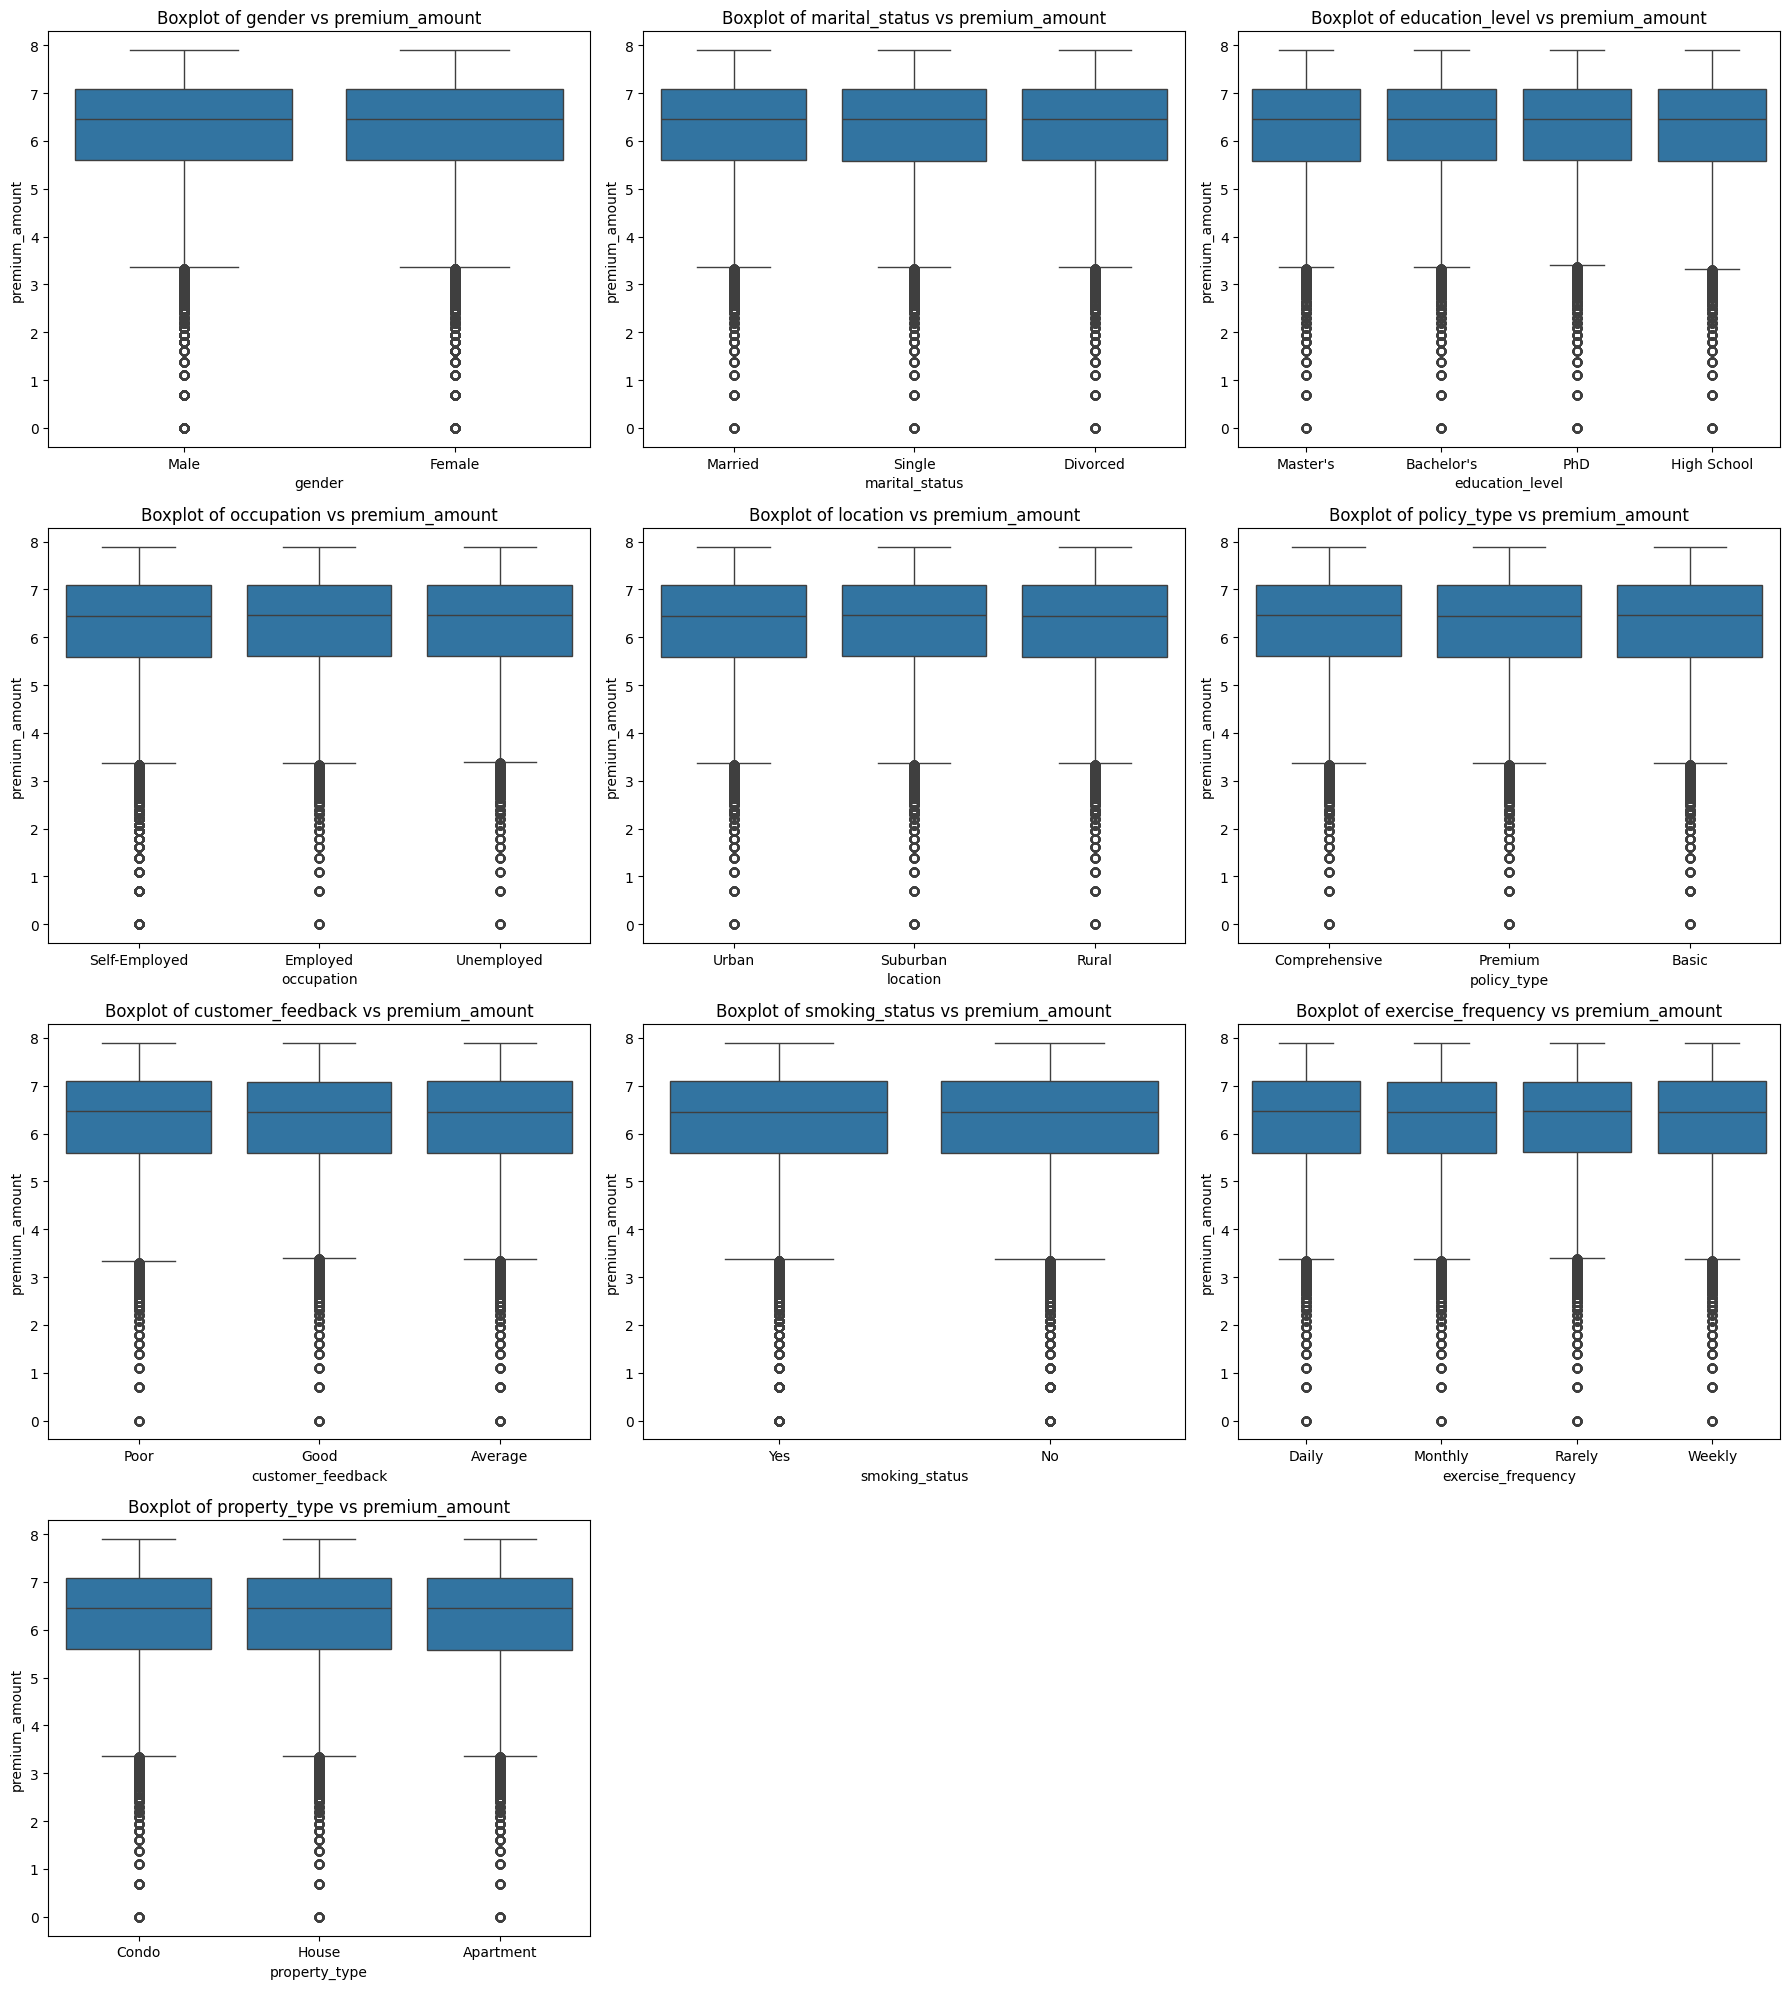

In [44]:
def bivariate_analysis(df, target='premium_amount'):
    # Select only categorical features (excluding the target if it's categorical)
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    if target in cat_cols:
        cat_cols = cat_cols.drop(target)

    num_plots = len(cat_cols)
    rows = (num_plots // 3) + 1
    
    fig, axes = plt.subplots(nrows=rows, ncols=3, figsize=(18, 5 * rows))
    axes = axes.flatten()

    for i, col_name in enumerate(cat_cols):
        sns.boxplot(data=df, x=col_name, y=target, ax=axes[i])
        axes[i].set_title(f'Boxplot of {col_name} vs {target}')

    # Remove extra subplots if any
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

bivariate_analysis(df, target='premium_amount')

### Pairplot of Numerical Variables

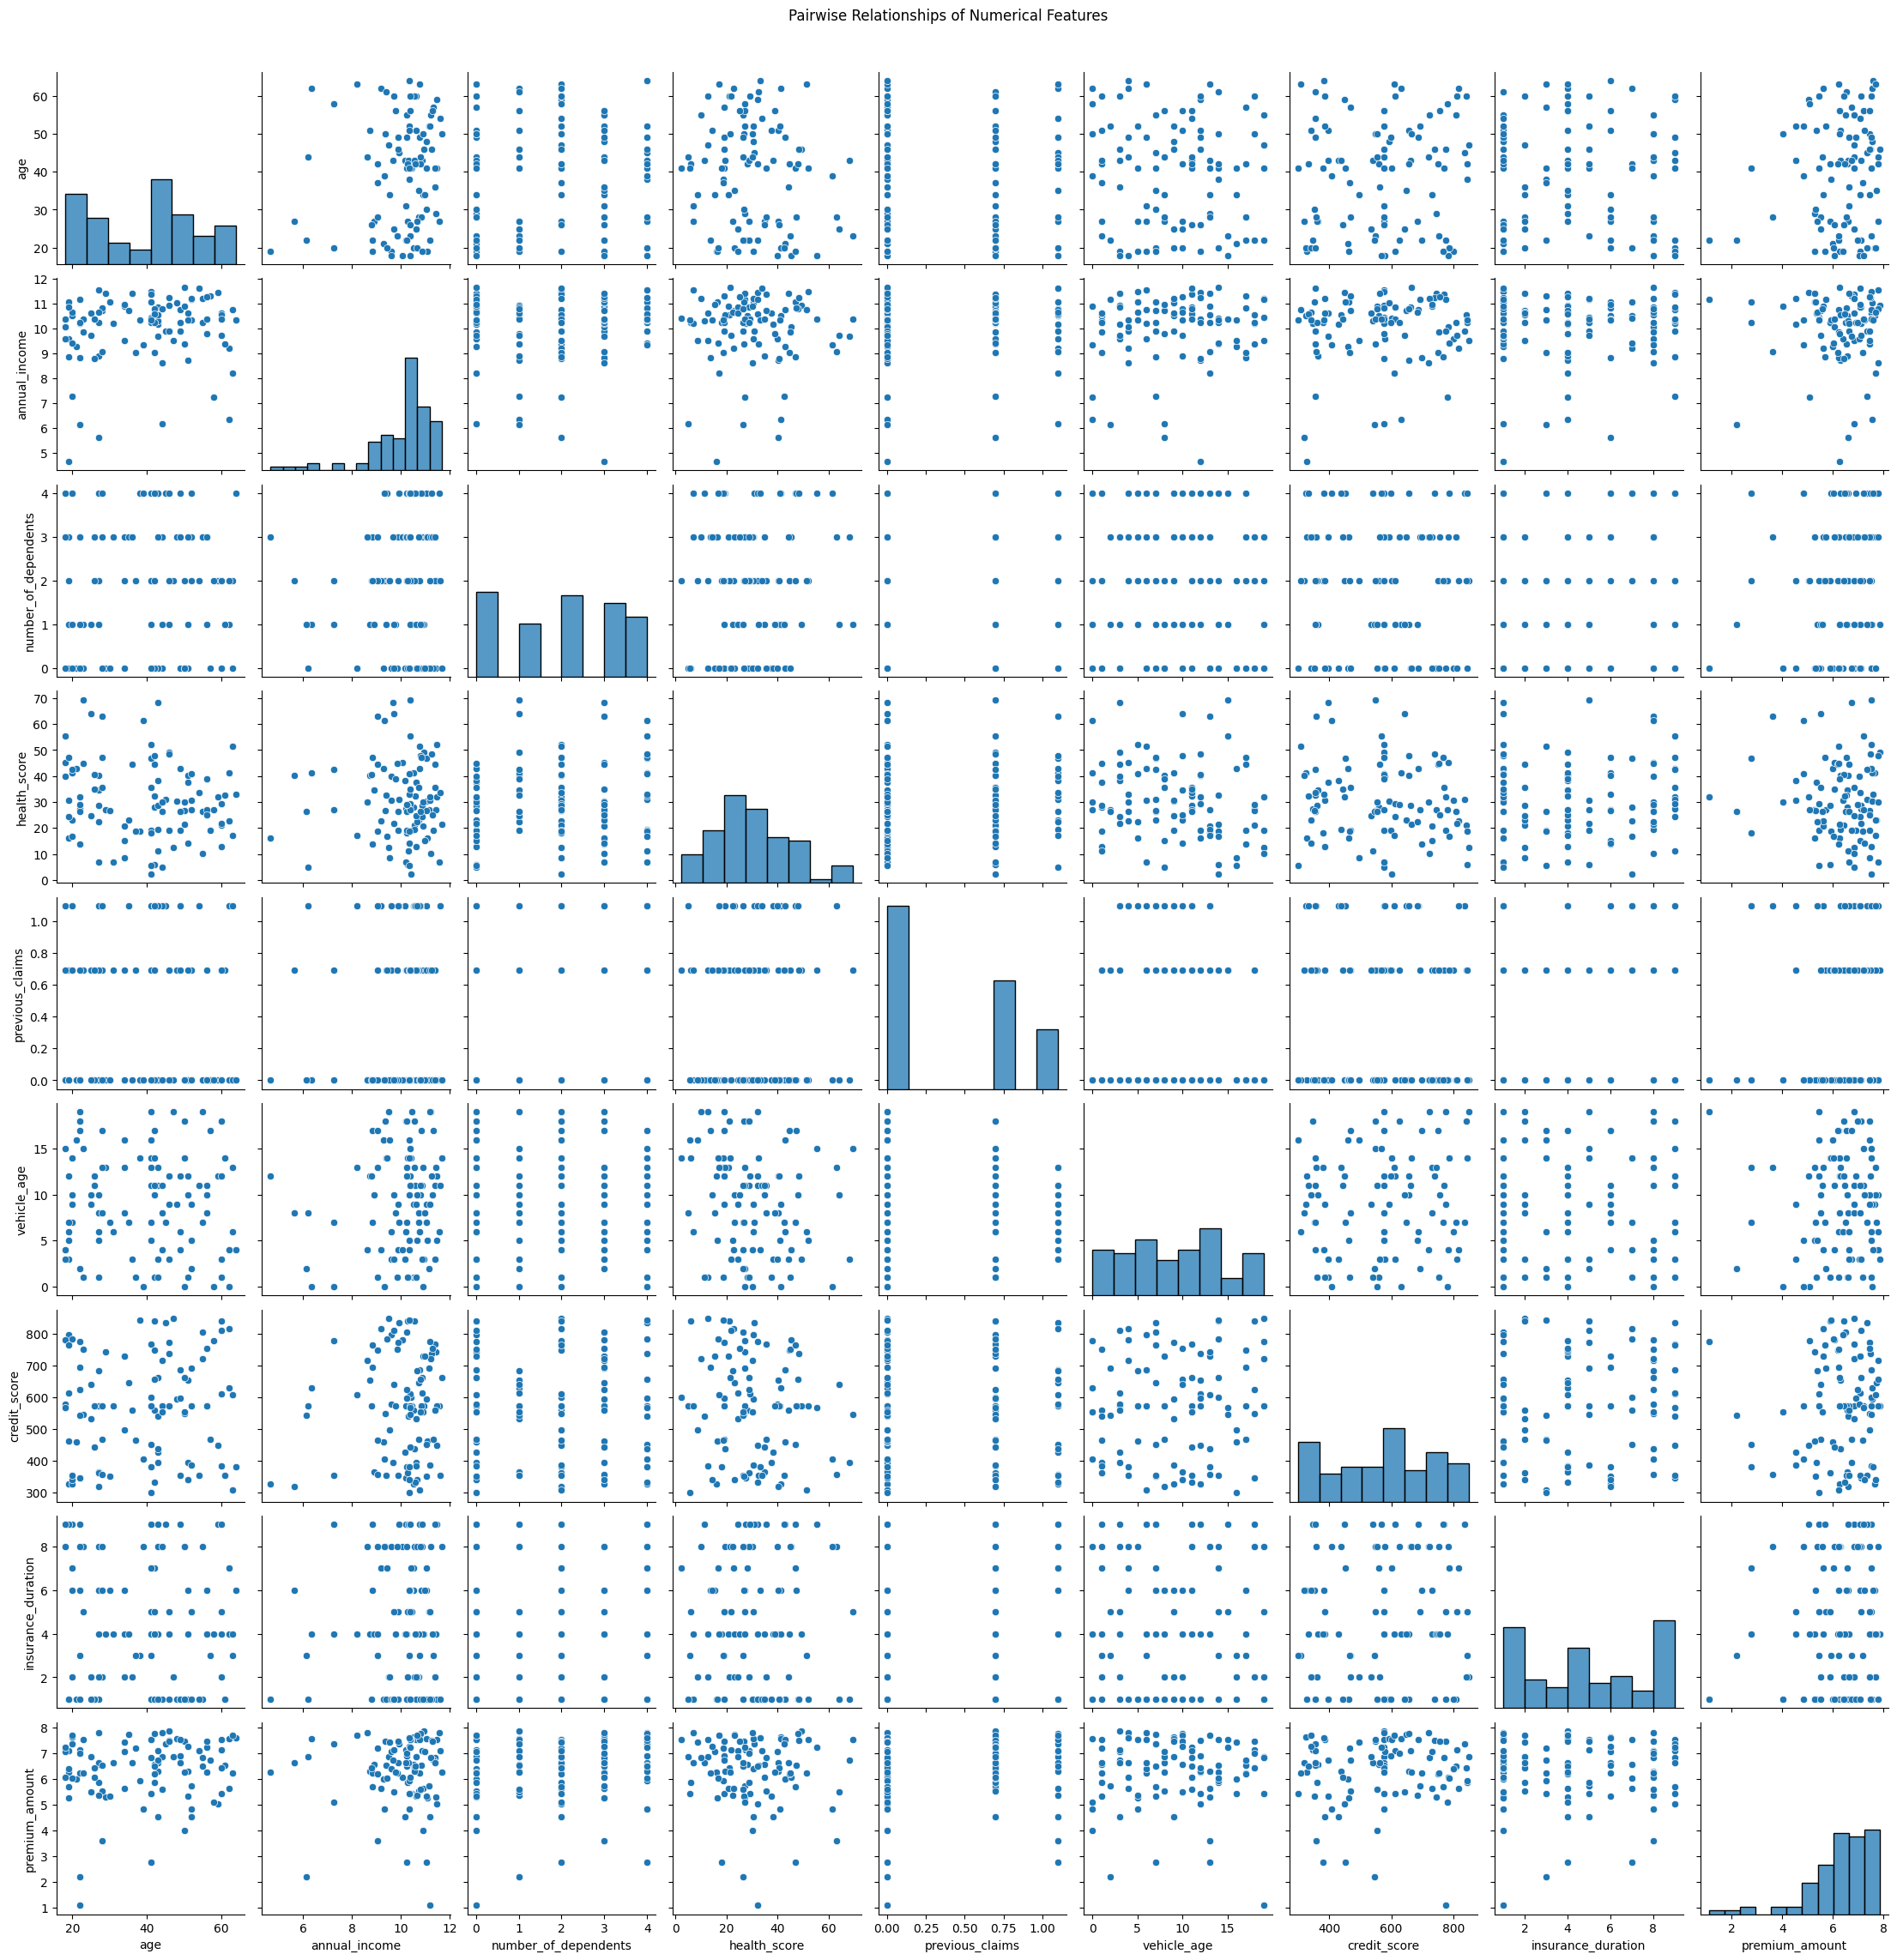

In [49]:
# Select only numerical columns for the pairplot
numerical_cols = df.select_dtypes(include=['number']).columns

# Plot pairplot (sample data to avoid crashing)
sns.pairplot(df[numerical_cols].sample(100, random_state=42))  # Sampling to reduce rendering time
plt.suptitle('Pairwise Relationships of Numerical Features', y=1.02)
plt.show()

<hr>

## Feature Engineering and Encoding
<hr>

### Feature Engineering

In [ ]:
df.head()

In [58]:
## Feature engineering - extracting new feature (years_since_policy_start) from policy_statrt_date

today = pd.to_datetime("today")

df['years_since_policy_start'] = (today - df['policy_start_date']).dt.days // 365
df.head()

,age,gender,annual_income,marital_status,number_of_dependents,education_level,occupation,health_score,location,policy_type,...,vehicle_age,credit_score,insurance_duration,premium_amount,policy_start_date,customer_feedback,smoking_status,exercise_frequency,property_type,years_since_policy_start
0,56,Male,11.512835,Married,1.0,Master's,Self-Employed,31.074627,Urban,Comprehensive,...,13,320.0,5,5.733341,2022-12-10 15:21:39.078837,Poor,Yes,Daily,Condo,2
1,46,Male,7.961370,Single,1.0,Bachelor's,Self-Employed,50.271335,Urban,Comprehensive,...,3,694.0,4,6.249975,2023-01-31 15:21:39.078837,Good,Yes,Monthly,House,2
2,32,Female,10.314106,Divorced,3.0,Bachelor's,Self-Employed,14.714909,Suburban,Comprehensive,...,16,652.0,8,6.745236,2023-11-26 15:21:39.078837,Poor,No,Monthly,House,1
3,60,Female,10.786676,Divorced,0.0,PhD,Self-Employed,25.346926,Rural,Comprehensive,...,11,330.0,7,6.833032,2023-02-27 15:21:39.078837,Poor,No,Rarely,Condo,2
4,25,Female,10.899975,Divorced,0.0,High School,Self-Employed,6.659499,Urban,Comprehensive,...,9,575.0,8,5.717028,2020-11-25 15:21:39.078837,Poor,No,Rarely,Condo,4


### Feature Encoding

In [110]:
## Categorical Feature Encoding using OneHotEncoder and OrdinalEncoder

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# Scaling numerical features using StandardScaler
numerical_features = ['age', 'annual_income', 'number_of_dependents', 'health_score',
                      'previous_claims', 'vehicle_age', 'credit_score',
                      'insurance_duration', 'years_since_policy_start']

# Define the transformer
transformer = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    # Ordinal encodings
    ('edu', OrdinalEncoder(
        categories=[["High School", "Bachelor's", "Master's", "PhD"]],
        dtype='int64',
        handle_unknown='use_encoded_value',
        unknown_value=-1,
        encoded_missing_value=-5
    ), ['education_level']),

    ('exercise', OrdinalEncoder(
        categories=[['Rarely', 'Daily', 'Weekly', 'Monthly']],
        dtype='int64',
        handle_unknown='use_encoded_value',
        unknown_value=-1,
        encoded_missing_value=-5
    ), ['exercise_frequency']),

    # OneHot encoding for nominal features
    ('onehot', OneHotEncoder(
        drop='first',
        handle_unknown='ignore',
        sparse_output=False
    ), [
        'gender', 'marital_status', 'location', 'policy_type',
        'customer_feedback', 'smoking_status', 'property_type'
    ]),

    # Occupation (OneHot for now)
    ('occupation', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['occupation'])

], remainder='drop')  # Drop any unlisted columns (e.g., policy_start_date)

## Model Development

In [111]:
# import libraries

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Model definitions
models = {
    'LinearRegression': LinearRegression(),
    # 'KNNRegressor': KNeighborsRegressor(),
    # 'DecisionTreeRegressor': DecisionTreeRegressor(),
    'RandomForest': RandomForestRegressor(random_state=42)
    # 'GradientBoosting': GradientBoostingRegressor(random_state=42),
    # 'SVR': SVR(),
    # 'Ridge': Ridge(random_state=42)
}

# Prepare data
X = df.drop('premium_amount', axis=1)
y = df['premium_amount']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Evaluate baseline models
results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessing', transformer),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred),
        'R²': r2_score(y_test, y_pred)
    })

# Show baseline results
results_df = pd.DataFrame(results).sort_values(by='R²', ascending=False)
print("Baseline Model Results:")
print(results_df)

Baseline Model Results:
              Model       MAE       MSE        R²
0  LinearRegression  0.798449  0.953649 -0.000056
1      RandomForest  0.810782  0.971701 -0.018987


## Hyperparameter Tuning

In [127]:
from sklearn.model_selection import GridSearchCV

print("\n Running Optimized GridSearchCV on RandomForest...")

rf_pipeline = Pipeline(steps=[
    ('preprocessing', transformer),
    ('model', RandomForestRegressor(random_state=42))
])

# Smaller grid
param_grid = {
    'model__n_estimators': [100],
    'model__max_depth': [10, None],
    'model__min_samples_split': [2],
    'model__min_samples_leaf': [1, 2]
}

# Faster CV
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=2,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
y_pred_grid = grid_search.predict(X_test)

# Results
print("\n Best Parameters:", grid_search.best_params_)
print("MAE:", mean_absolute_error(y_test, y_pred_grid))
print("MSE:", mean_squared_error(y_test, y_pred_grid))
print("R²:", r2_score(y_test, y_pred_grid))


 Running Optimized GridSearchCV on RandomForest...
Fitting 2 folds for each of 4 candidates, totalling 8 fits

 Best Parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}
MAE: 0.7989310662235015
MSE: 0.9543482032451747
R²: -0.000789570198945766


### Handling Overfitting in RandomForestRegressor

In [128]:
RandomForestRegressor(
    max_depth=10, 
    n_estimators=100, 
    min_samples_split=5, 
    min_samples_leaf=2
)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5)

### Handling Underfitting in RandomForestRegressor

In [129]:
# Add complexity

RandomForestRegressor(
    max_depth=None,
    n_estimators=300
)

RandomForestRegressor(n_estimators=300)

### Evaluate Overfitting and Underfitting After Fixes

In [131]:
from sklearn.metrics import r2_score

# Use the fitted pipeline or GridSearchCV object
fitted_pipeline = grid_search.best_estimator_

r2_train = r2_score(y_train, fitted_pipeline.predict(X_train))
r2_test = r2_score(y_test, fitted_pipeline.predict(X_test))

print(f"Train R²: {r2_train:.3f}, Test R²: {r2_test:.3f}")

Train R²: 0.021, Test R²: -0.001


### Feature Importance Analysis to Understand the Drivers of Insurance Premiums

In [132]:
# Get fitted model and transformer
model = pipeline.named_steps['model']
preprocessor = pipeline.named_steps['preprocessing']

# 1. Numerical features (Scaler just passes them)
num_features = preprocessor.transformers_[0][2]

# 2. Ordinal encoded features (same names)
edu_features = preprocessor.transformers_[1][2]
exercise_features = preprocessor.transformers_[2][2]

# 3. OneHotEncoder feature names
onehot_features = preprocessor.named_transformers_['onehot'].get_feature_names_out(
    preprocessor.transformers_[3][2]
)

# 4. Occupation OneHotEncoder
occupation_features = preprocessor.named_transformers_['occupation'].get_feature_names_out(
    preprocessor.transformers_[4][2]
)

# Combine all feature names
features = list(num_features) + list(edu_features) + list(exercise_features) + \
           list(onehot_features) + list(occupation_features)

# Now access feature importances
importances = model.feature_importances_

# Combine into DataFrame
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances})
print(feat_imp.sort_values(by='Importance', ascending=False).head(10))


                     Feature  Importance
3               health_score    0.146719
1              annual_income    0.145465
6               credit_score    0.127687
0                        age    0.088154
5                vehicle_age    0.077313
7         insurance_duration    0.058193
8   years_since_policy_start    0.042941
2       number_of_dependents    0.040928
10        exercise_frequency    0.033238
9            education_level    0.033181


### Top 10 Important Features Driving our Insurance Premium Amount

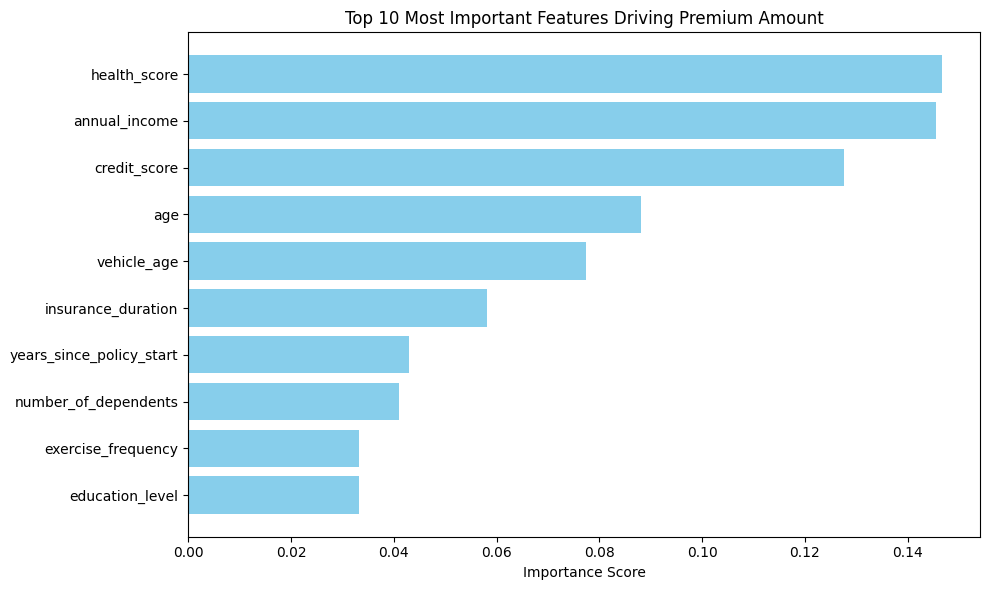

In [135]:
import matplotlib.pyplot as plt

# Sort and plot top 10 features
top_n = 10
top_features = feat_imp.sort_values(by='Importance', ascending=False).head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1], color='skyblue')
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Most Important Features Driving Premium Amount')

plt.tight_layout()
plt.show()

<hr>

## Actionable Insights from the Insurance Premium Prediction Model

### Summary of Top Influential Features

| Rank | Feature                    | Importance | Interpretation                                                                 |
|------|----------------------------|------------|---------------------------------------------------------------------------------|
| 1    | `health_score`             | 0.1467     | Healthier individuals tend to have lower risk and may be charged lower premiums. |
| 2    | `annual_income`            | 0.1455     | Higher-income customers are likely to afford or be offered higher coverage.     |
| 3    | `credit_score`             | 0.1277     | Strong financial behavior correlates with lower risk and affects premium rates. |
| 4    | `age`                      | 0.0882     | Age affects risk category—both very young and elderly may have higher risk.     |
| 5    | `vehicle_age`             | 0.0773     | Older vehicles typically come with increased risk or reduced coverage value.    |
| 6    | `insurance_duration`       | 0.0582     | Long-standing customers may qualify for loyalty-based discounts or adjustments. |
| 7    | `years_since_policy_start`| 0.0429     | Policy tenure could be a retention indicator—important for retention strategies.|
| 8    | `number_of_dependents`     | 0.0409     | More dependents may influence the extent of coverage required.                  |
| 9    | `exercise_frequency`       | 0.0332     | Active lifestyles reduce health risk, supporting wellness-based pricing.        |
| 10   | `education_level`          | 0.0332     | Higher education levels may correlate with more informed insurance choices.     |

<hr>

## Actionable Business Insights
**1. Wellness Programs Can Lower Premium Costs**:
Since health_score and exercise_frequency are among the top drivers:

- Introduce incentives for healthy behavior (e.g., gym memberships, health checkups).

- Offer discounts or lower premiums for customers with high health scores or consistent exercise habits.

**2. Income-Based Product Structuring**:
With annual_income as a key feature:

- Design tiered products aligned with customer income segments (e.g., premium vs. basic coverage).

- Offer bundled plans or loyalty rewards for high-income customers who often seek broader coverage.

**3. Credit Risk Should Influence Premium Pricing**:
Given the high importance of credit_score:

- Use credit score bands to differentiate pricing or coverage eligibility.

- Partner with financial institutions to offer insurance to creditworthy clients as add-on services.

**4. Policy Tenure Can Help Retain Loyal Clients**:
With insurance_duration and years_since_policy_start being important:

- Launch renewal reward programs or pricing discounts based on loyalty.

- Use tenure data to predict churn and proactively retain at-risk long-term customers.

**5. Customize Coverage Based on Vehicle & Customer Age**:
- Clients with older vehicles may need different coverage tiers or depreciation clauses.

- Age-specific plans (e.g., youth or senior plans) can better match risk and expectations.

**6. Targeted Family Plans**:
Since number_of_dependents has predictive value:

- Create family packages with flexible dependents coverage.

- Use dependents data to upsell health or life policies bundled with existing plans.

**7. Educational Campaigns & Segmentation**:
With education_level showing influence:

- Use educational segments to tailor messaging and product presentation.

- Offer educational content on insurance value to improve conversions among less-informed segments.

# **THE END!!!**